In [1]:
# Import required libraries for this Invoice Extraction Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

In [3]:
# Load the dataset invoice.csv download from kaggle

# uaing pandas read csv file and extract data from it 
data = pd.read_csv('invoices.csv')

# Display basic information of dataset total rows, total columns, column names and first 5 rowns of dataset
print("INVOICE DATASET LOADED")
print(f"Total rows : {data.shape[0]}")
print(f"Total columns : {data.shape[1]}")
print(f"\nColumn names : ")
print(data.columns.tolist())

print(f"\nFirst 5 rows : ")
print(data.head())

INVOICE DATASET LOADED
Total rows : 10000
Total columns : 11

Column names : 
['first_name', 'last_name', 'email', 'product_id', 'qty', 'amount', 'invoice_date', 'address', 'city', 'stock_code', 'job']

First 5 rows : 
            first_name      last_name                      email  product_id  \
0         Carmen Nixon  Todd Anderson  marvinjackson@example.com         133   
1  Mrs. Heather Miller    Julia Moore      jeffrey84@example.net         155   
2          Crystal May   Philip Moody       ugoodman@example.com         151   
3          Bobby Weber     Mark Scott       ssanchez@example.com         143   
4        Kristen Welch    David David      cynthia66@example.net         168   

   qty  amount invoice_date                          address            city  \
0    9   14.57   10/09/1982                 283 Wendy Common  West Alexander   
1    5   65.48   03/10/2012  13567 Patricia Circles Apt. 751     Andreamouth   
2    9   24.66   23/03/1976     6389 Debbie Island Suite 470

In [4]:
# Explore the dataset structure 

# Data types
print("\nData Types:")
print(data.dtypes)

# Find missing values
print("\nMissing Values:")
missing = data.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "No missing values found!")

# Basic statistics for numeric columns
print("\nStatistical Summary (Numeric Columns):")
print(data.describe())


Data Types:
first_name       object
last_name        object
email            object
product_id        int64
qty               int64
amount          float64
invoice_date     object
address          object
city             object
stock_code        int64
job              object
dtype: object

Missing Values:
No missing values found!

Statistical Summary (Numeric Columns):
         product_id           qty        amount    stock_code
count  10000.000000  10000.000000  10000.000000  1.000000e+04
mean     149.746700      5.005900     52.918236  4.950036e+07
std       28.728186      2.576767     27.434579  2.903081e+07
min      100.000000      1.000000      5.010000  1.977000e+03
25%      125.000000      3.000000     29.137500  2.425234e+07
50%      150.000000      5.000000     53.485000  4.931714e+07
75%      175.000000      7.000000     76.520000  7.457446e+07
max      199.000000      9.000000     99.990000  9.999216e+07


In [5]:
# Clean and prepare the data

print("Data Cleaning....!")

# Find duplicate rows from data
duplicates = data.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Remove duplicates 
if duplicates > 0:
    data = data.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")

# Convert amount to numeric if needed (already numeric)
data['amount'] = pd.to_numeric(data['amount'], errors='coerce')

# Convert invoice_date to datetime
data['invoice_date'] = pd.to_datetime(data['invoice_date'], errors='coerce')

# Create full name column from first_name and last_name
data['customer_name'] = data['first_name'] + ' ' + data['last_name']

# Create a unique invoice ID
data['invoice_id'] = range(1, len(data) + 1)

print(f"\nAfter cleaning: {len(data)} rows")
print(f"Date range: {data['invoice_date'].min()} to {data['invoice_date'].max()}")
print(f"Amount range: ${data['amount'].min():.2f} to ${data['amount'].max():.2f}")

Data Cleaning....!
Duplicate rows: 0

After cleaning: 10000 rows
Date range: 1970-01-06 00:00:00 to 2022-09-01 00:00:00
Amount range: $5.01 to $99.99


In [6]:
# Create invoice summary statistics

print("Invoice Summary Statistics...!")

# Total revenue
total_revenue = data['amount'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

# Average invoice amount
avg_amount = data['amount'].mean()
print(f"Average Invoice Amount: ${avg_amount:.2f}")

# Median invoice amount
median_amount = data['amount'].median()
print(f"Median Invoice Amount: ${median_amount:.2f}")

# Total quantity sold
total_quantity = data['qty'].sum()
print(f"Total Quantity Sold: {total_quantity:,}")

# Number of unique products
unique_products = data['product_id'].nunique()
print(f"Unique Products: {unique_products}")

# Number of unique customers
unique_customers = data['email'].nunique()
print(f"Unique Customers: {unique_customers}")

# Create summary DataFrame
summary_stats = pd.DataFrame({
    'Metric': ['Total Revenue', 'Average Invoice', 'Median Invoice', 
               'Total Quantity', 'Unique Products', 'Unique Customers'],
    'Value': [f'${total_revenue:,.2f}', f'${avg_amount:.2f}', f'${median_amount:.2f}',
              f'{total_quantity:,}', unique_products, unique_customers]
})
print("\nSummary Table:")
print(summary_stats.to_string(index=False))

Invoice Summary Statistics...!
Total Revenue: $529,182.36
Average Invoice Amount: $52.92
Median Invoice Amount: $53.48
Total Quantity Sold: 50,059
Unique Products: 100
Unique Customers: 9769

Summary Table:
          Metric       Value
   Total Revenue $529,182.36
 Average Invoice      $52.92
  Median Invoice      $53.48
  Total Quantity      50,059
 Unique Products         100
Unique Customers        9769


In [7]:
# Analyze by product

print("Top 10 Products By Revenue...!")

# Group by product_id
product_performance = data.groupby('product_id').agg({
    'amount': ['sum', 'mean', 'count'],
    'qty': 'sum'
}).round(2)

product_performance.columns = ['total_revenue', 'avg_amount', 'transaction_count', 'total_quantity']
product_performance = product_performance.sort_values('total_revenue', ascending=False)

print(product_performance.head(10))

# Top products visualization data
top_products = product_performance.head(10).reset_index()
print(f"\nTop Product: ID {top_products.iloc[0]['product_id']} with ${top_products.iloc[0]['total_revenue']:,.2f} revenue")

Top 10 Products By Revenue...!
            total_revenue  avg_amount  transaction_count  total_quantity
product_id                                                              
164               7063.05       53.92                131             775
128               6768.94       56.88                119             631
104               6505.23       55.13                118             584
145               6458.13       51.26                126             628
196               6314.91       54.91                115             518
108               6235.86       55.68                112             605
165               6207.84       54.94                113             570
171               6130.90       55.74                110             571
143               6041.02       52.99                114             626
186               5969.72       57.96                103             521

Top Product: ID 164.0 with $7,063.05 revenue


In [8]:
# Analyze by customer

print("Top 10 Customers By Spending...!")

# Group by customer (using email as unique identifier)
customer_spending = data.groupby(['email', 'customer_name']).agg({
    'amount': ['sum', 'mean', 'count'],
    'qty': 'sum'
}).round(2)

customer_spending.columns = ['total_spent', 'avg_order_value', 'order_count', 'total_quantity']
customer_spending = customer_spending.sort_values('total_spent', ascending=False)

print(customer_spending.head(10))

# Most frequent customers
print("\nTOP 10 CUSTOMERS BY ORDER FREQUENCY:")
print(customer_spending.nlargest(10, 'order_count')[['order_count', 'total_spent']])

Top 10 Customers By Spending...!
                                                              total_spent  \
email                      customer_name                                    
tiffany16@example.org      Anthony Wright Amy Tyler                 99.99   
carly46@example.org        Evan Mccoy Stephen Thornton              99.99   
wmitchell@example.com      Derek Thompson Dennis Jackson            99.99   
danielle23@example.org     Alexis Carey Jeffrey Nelson              99.98   
friedmancheryl@example.org Taylor Downs Allen Jordan                99.96   
heathervaldez@example.org  Jennifer Mccarthy Patricia Ruiz          99.93   
zpierce@example.net        Andrew Berger Janice Alvarez DDS         99.91   
michaelsmith@example.com   Chelsea Anderson Margaret Mathews        99.90   
juan57@example.org         Steven Tucker Kenneth Chen               99.90   
qbarrett@example.net       Lindsey Williams Harold Wilson           99.89   

                                          

In [9]:
# Time-based analysis

print("Time-Based Analysis...!")

# Extract date components
data['year'] = data['invoice_date'].dt.year
data['month'] = data['invoice_date'].dt.month
data['quarter'] = data['invoice_date'].dt.quarter
data['day_of_week'] = data['invoice_date'].dt.day_name()

# Revenue by year
yearly_revenue = data.groupby('year')['amount'].sum().sort_index()
print("\nRevenue by Year:")
for year, revenue in yearly_revenue.items():
    print(f"   {year}: ${revenue:,.2f}")

# Revenue by month (across all years)
monthly_revenue = data.groupby('month')['amount'].sum().sort_index()
print("\nRevenue by Month (all years combined):")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month in range(1, 13):
    if month in monthly_revenue.index:
        print(f"   {month_names[month-1]}: ${monthly_revenue[month]:,.2f}")

# Revenue by day of week
daily_revenue = data.groupby('day_of_week')['amount'].sum().sort_values(ascending=False)
print("\nRevenue by Day of Week:")
for day, revenue in daily_revenue.items():
    print(f"   {day}: ${revenue:,.2f}")

Time-Based Analysis...!

Revenue by Year:
   1970.0: $4,593.03
   1971.0: $3,789.05
   1972.0: $4,213.71
   1973.0: $3,788.34
   1974.0: $4,506.59
   1975.0: $4,428.31
   1976.0: $3,858.80
   1977.0: $3,835.38
   1978.0: $5,035.36
   1979.0: $4,394.04
   1980.0: $4,129.13
   1981.0: $3,609.05
   1982.0: $4,135.92
   1983.0: $4,153.60
   1984.0: $3,482.00
   1985.0: $3,236.11
   1986.0: $4,114.76
   1987.0: $3,747.62
   1988.0: $4,729.36
   1989.0: $5,121.85
   1990.0: $4,089.87
   1991.0: $3,596.73
   1992.0: $4,137.83
   1993.0: $5,148.89
   1994.0: $4,723.43
   1995.0: $3,510.54
   1996.0: $3,999.76
   1997.0: $3,368.36
   1998.0: $3,742.15
   1999.0: $3,485.76
   2000.0: $3,755.97
   2001.0: $3,452.05
   2002.0: $3,629.01
   2003.0: $4,139.48
   2004.0: $3,768.29
   2005.0: $3,996.18
   2006.0: $4,035.56
   2007.0: $3,890.29
   2008.0: $4,173.99
   2009.0: $4,143.22
   2010.0: $3,250.35
   2011.0: $3,670.89
   2012.0: $3,364.79
   2013.0: $3,711.06
   2014.0: $3,782.35
   2015.0: $4

In [10]:
# Job/Profession analysis

print("Top Professions By Spending...!")

# Clean job titles (remove quotes if present)
data['job_clean'] = data['job'].str.strip().str.replace('"', '')

# Group by job
job_spending = data.groupby('job_clean').agg({
    'amount': ['sum', 'mean', 'count']
}).round(2)

job_spending.columns = ['total_spent', 'avg_spent', 'transaction_count']
job_spending = job_spending.sort_values('total_spent', ascending=False)

print(job_spending.head(15))

print(f"\nTop spending profession: {job_spending.index[0]} (${job_spending.iloc[0]['total_spent']:,.2f})")

Top Professions By Spending...!
                                     total_spent  avg_spent  transaction_count
job_clean                                                                     
Producer, radio                          1685.16      62.41                 27
Engineer, broadcasting (operations)      1611.94      64.48                 25
Agricultural consultant                  1579.46      56.41                 28
Corporate treasurer                      1544.56      64.36                 24
Commercial/residential surveyor          1499.97      60.00                 25
Heritage manager                         1472.73      56.64                 26
Colour technologist                      1435.39      62.41                 23
Clothing/textile technologist            1435.17      75.54                 19
Research scientist (life sciences)       1422.13      49.04                 29
Geochemist                               1414.39      56.58                 25
Engineer, manufactur

In [11]:
# Geographic analysis (by city)

print("Top Cities By Revenue")

city_revenue = data.groupby('city').agg({
    'amount': ['sum', 'mean', 'count']
}).round(2)

city_revenue.columns = ['total_revenue', 'avg_order', 'order_count']
city_revenue = city_revenue.sort_values('total_revenue', ascending=False)

print(city_revenue.head(15))

print(f"\nTop city: {city_revenue.index[0]} (${city_revenue.iloc[0]['total_revenue']:,.2f})")

Top Cities By Revenue
                total_revenue  avg_order  order_count
city                                                 
Lake James             778.43      64.87           12
North Jason            535.47      66.93            8
South Jennifer         485.80      53.98            9
Smithmouth             469.65      58.71            8
North Michael          467.32      58.42            8
Port Kimberly          459.76      76.63            6
Michaelshire           459.13      65.59            7
North Jennifer         439.00      62.71            7
New Jennifer           424.00      70.67            6
Lake Michael           422.35      46.93            9
Lake Jennifer          408.93      68.16            6
Port Joshua            405.12      57.87            7
South James            403.92      40.39           10
North Andrew           390.57      65.10            6
Port Amber             390.24      78.05            5

Top city: Lake James ($778.43)


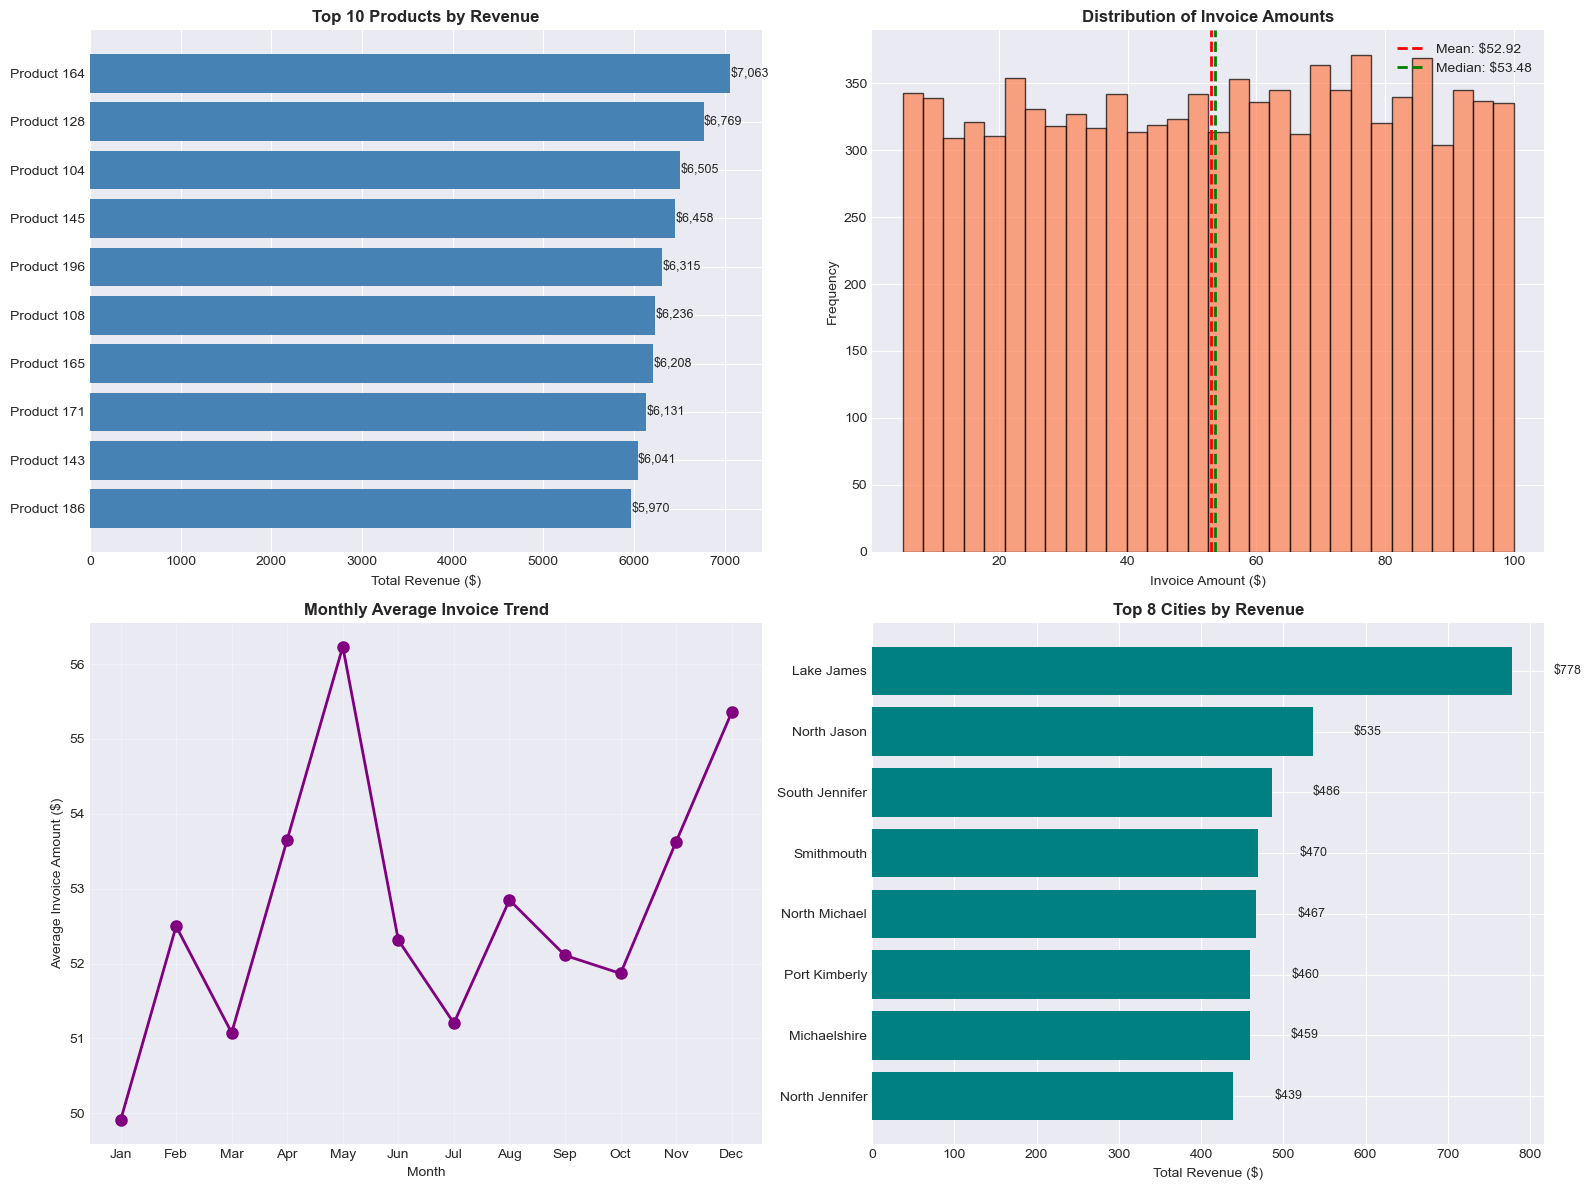

Dashboard saved as 'invoice_analysis_dashboard.png'


In [14]:
# Create visualizations

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Revenue by Product (Top 10)
ax1 = fig.add_subplot(2, 2, 1)
top_products_plot = product_performance.head(10)
bars = ax1.barh(range(len(top_products_plot)), top_products_plot['total_revenue'].values, color='steelblue')
ax1.set_yticks(range(len(top_products_plot)))
ax1.set_yticklabels([f'Product {int(x)}' for x in top_products_plot.index])
ax1.set_xlabel('Total Revenue ($)')
ax1.set_title('Top 10 Products by Revenue', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_products_plot['total_revenue'].values)):
    ax1.text(val + 5, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', 
             va='center', fontsize=9)

# 2. Revenue Distribution Histogram
ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(data['amount'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(data['amount'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: ${data["amount"].mean():.2f}')
ax2.axvline(data['amount'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: ${data["amount"].median():.2f}')
ax2.set_xlabel('Invoice Amount ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Invoice Amounts', fontsize=12, fontweight='bold')
ax2.legend()

# 3. Monthly Revenue Trend
ax3 = fig.add_subplot(2, 2, 3)
data['month_num'] = data['invoice_date'].dt.month
monthly_avg = data.groupby('month_num')['amount'].mean()
ax3.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='purple')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax3.set_xlabel('Month')
ax3.set_ylabel('Average Invoice Amount ($)')
ax3.set_title('Monthly Average Invoice Trend', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Top Cities by Revenue
ax4 = fig.add_subplot(2, 2, 4)
top_cities = city_revenue.head(8)
bars = ax4.barh(range(len(top_cities)), top_cities['total_revenue'].values, color='teal')
ax4.set_yticks(range(len(top_cities)))
ax4.set_yticklabels(top_cities.index)
ax4.set_xlabel('Total Revenue ($)')
ax4.set_title('Top 8 Cities by Revenue', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_cities['total_revenue'].values)):
    ax4.text(val + 50, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', 
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig('invoice_analysis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as 'invoice_analysis_dashboard.png'")

In [15]:
# Create pivot tables for deeper analysis

print("Pivot Table Analysis...!")

# Pivot table: Product vs City
print("\n1️. Top 5 Products by Top 5 Cities...!")
top_products_list = product_performance.head(5).index.tolist()
top_cities_list = city_revenue.head(5).index.tolist()

pivot_product_city = pd.pivot_table(
    data[data['product_id'].isin(top_products_list) & data['city'].isin(top_cities_list)],
    values='amount',
    index='product_id',
    columns='city',
    aggfunc='sum',
    fill_value=0
).round(2)

print(pivot_product_city)

# Pivot table: Year vs Quarter
print("\n2️. Revenue by Year and Quarter:")
pivot_year_quarter = pd.pivot_table(
    data,
    values='amount',
    index='year',
    columns='quarter',
    aggfunc='sum',
    fill_value=0
).round(2)

print(pivot_year_quarter)

# Pivot table: Day of Week vs Month
print("\n3️. Average Order Value by Day and Month:")
# Create month name
data['month_name'] = data['invoice_date'].dt.strftime('%B')
pivot_day_month = pd.pivot_table(
    data,
    values='amount',
    index='day_of_week',
    columns='month_name',
    aggfunc='mean',
    fill_value=0
).round(2)

print(pivot_day_month)

Pivot Table Analysis...!

1️. Top 5 Products by Top 5 Cities...!
city        Lake James  North Jason  North Michael  South Jennifer
product_id                                                        
104              92.13         0.00           0.00            0.00
164               0.00         0.00           0.00           68.25
196               0.00        85.72          10.91            0.00

2️. Revenue by Year and Quarter:
quarter      1.0      2.0      3.0      4.0
year                                       
1970.0   1377.20  1219.41   697.76  1298.66
1971.0   1222.27   839.34   935.76   791.68
1972.0    718.92  1367.02  1527.07   600.70
1973.0    794.21   622.48  1416.63   955.02
1974.0   1011.24  1226.90  1028.96  1239.49
1975.0   1142.66  1079.86  1188.21  1017.58
1976.0    479.90  1449.36  1051.95   877.59
1977.0    538.57   363.03  1568.60  1365.18
1978.0   1241.63   960.53  1586.85  1246.35
1979.0    940.91  1325.96  1088.89  1038.28
1980.0    820.14   909.14  1167.91  12

In [16]:
# Find high-value insights

print("Key Inights and Findings...!")

# 1. Top 5 highest value single transactions
top_transactions = data.nlargest(5, 'amount')[['invoice_id', 'customer_name', 'product_id', 'qty', 'amount', 'invoice_date']]
print("\nTOP 5 Highest Value Transactions : ")
print(top_transactions.to_string(index=False))

# 2. Customer lifetime value segments
customer_clv = customer_spending.copy()
customer_clv['segment'] = pd.cut(
    customer_clv['total_spent'],
    bins=[0, 100, 500, 1000, float('inf')],
    labels=['Bronze (<$100)', 'Silver ($100-$500)', 'Gold ($500-$1000)', 'Platinum ($1000+)']
)

print("\nCustomer Segmentation : ")
segment_counts = customer_clv['segment'].value_counts()
for segment, count in segment_counts.items():
    print(f"   {segment}: {count} customers")

# 3. Best selling products by quantity
top_quantity = data.groupby('product_id')['qty'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Products By Quantity Sold : ")
for product, qty in top_quantity.items():
    print(f"   Product {product}: {qty} units")

# 4. Seasonal patterns
data['month_name'] = data['invoice_date'].dt.strftime('%B')
monthly_total = data.groupby('month_name')['amount'].sum().sort_values(ascending=False)
print("\nBest Months For Revenue:")
for month, revenue in monthly_total.head(3).items():
    print(f"   {month}: ${revenue:,.2f}")

Key Inights and Findings...!

TOP 5 Highest Value Transactions : 
 invoice_id                 customer_name  product_id  qty  amount invoice_date
       4272 Derek Thompson Dennis Jackson         181    3   99.99          NaT
       6909      Anthony Wright Amy Tyler         157    8   99.99          NaT
       7250   Evan Mccoy Stephen Thornton         167    4   99.99          NaT
       5528   Alexis Carey Jeffrey Nelson         109    1   99.98   1992-05-07
       3119     Taylor Downs Allen Jordan         183    7   99.96   2016-05-03

Customer Segmentation : 
   Bronze (<$100): 10000 customers
   Silver ($100-$500): 0 customers
   Gold ($500-$1000): 0 customers
   Platinum ($1000+): 0 customers

Top 5 Products By Quantity Sold : 
   Product 164: 775 units
   Product 128: 631 units
   Product 145: 628 units
   Product 143: 626 units
   Product 108: 605 units

Best Months For Revenue:
   August: $19,025.48
   September: $18,186.11
   May: $18,163.62


In [17]:
# Export processed data to Excel

print("Exporting Processed Data...!")

# Create a comprehensive Excel file with multiple sheets
output_filename = 'invoice_analysis_report.xlsx'

with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
    # Original data (cleaned)
    data_export = data[[
        'invoice_id', 'customer_name', 'email', 'product_id', 'qty', 
        'amount', 'invoice_date', 'city', 'job_clean'
    ]].copy()
    data_export.to_excel(writer, sheet_name='All Invoices', index=False)
    
    # Summary statistics
    summary_data = pd.DataFrame([
        ['Total Revenue', f'${total_revenue:,.2f}'],
        ['Average Invoice', f'${avg_amount:.2f}'],
        ['Median Invoice', f'${median_amount:.2f}'],
        ['Total Transactions', len(data)],
        ['Total Customers', unique_customers],
        ['Unique Products', unique_products],
        ['Date Range Start', data['invoice_date'].min().strftime('%Y-%m-%d')],
        ['Date Range End', data['invoice_date'].max().strftime('%Y-%m-%d')]
    ], columns=['Metric', 'Value'])
    summary_data.to_excel(writer, sheet_name='Summary', index=False)
    
    # Top products
    product_performance.reset_index().to_excel(writer, sheet_name='Top Products', index=False)
    
    # Top customers
    customer_spending.reset_index().to_excel(writer, sheet_name='Top Customers', index=False)
    
    # Revenue by city
    city_revenue.reset_index().to_excel(writer, sheet_name='Revenue by City', index=False)
    
    # Revenue by profession
    job_spending.reset_index().to_excel(writer, sheet_name='Revenue by Profession', index=False)
    
    # Monthly trend
    monthly_trend = data.groupby(data['invoice_date'].dt.to_period('M'))['amount'].sum().reset_index()
    monthly_trend.columns = ['Month', 'Total Revenue']
    monthly_trend['Month'] = monthly_trend['Month'].astype(str)
    monthly_trend.to_excel(writer, sheet_name='Monthly Trend', index=False)

print(f"Report saved to: {output_filename}")
print(f"   - All Invoices sheet: {len(data)} rows")
print(f"   - Summary statistics")
print(f"   - Top products & customers")
print(f"   - Revenue by city & profession")
print(f"   - Monthly trend analysis")

Exporting Processed Data...!
Report saved to: invoice_analysis_report.xlsx
   - All Invoices sheet: 10000 rows
   - Summary statistics
   - Top products & customers
   - Revenue by city & profession
   - Monthly trend analysis


In [19]:
# Generate final summary report

print("INVOICE DATA EXTRACTION - COMPLETE SUMMARY REPORT")

print("\nBUSINESS METRICS:")
print(f"   • Total Revenue:          ${total_revenue:>15,.2f}")
print(f"   • Total Transactions:     {len(data):>15,}")
print(f"   • Average Order Value:    ${avg_amount:>15,.2f}")
print(f"   • Total Units Sold:       {total_quantity:>15,}")
print(f"   • Unique Customers:       {unique_customers:>15,}")
print(f"   • Unique Products:        {unique_products:>15,}")

print("\nTOP PERFORMERS:")
print(f"   • Best Product:           Product {product_performance.index[0]} (${product_performance.iloc[0]['total_revenue']:,.2f})")
print(f"   • Best Customer:          {customer_spending.index[0][1]} (${customer_spending.iloc[0]['total_spent']:,.2f})")
print(f"   • Best City:              {city_revenue.index[0]} (${city_revenue.iloc[0]['total_revenue']:,.2f})")
print(f"   • Best Profession:        {job_spending.index[0][:30]} (${job_spending.iloc[0]['total_spent']:,.2f})")

print("\nSEASONAL INSIGHTS:")
best_month = monthly_total.index[0]
print(f"   • Peak Revenue Month:     {best_month} (${monthly_total.iloc[0]:,.2f})")
print(f"   • Best Day of Week:       {daily_revenue.index[0]} (${daily_revenue.iloc[0]:,.2f})")

print("\nCUSTOMER INSIGHTS:")
print(f"   • Average Transactions:   {customer_spending['order_count'].mean():.1f} per customer")
print(f"   • Repeat Customers:       {(customer_spending['order_count'] > 1).sum()} customers")
print(f"   • One-time Customers:     {(customer_spending['order_count'] == 1).sum()} customers")

print("EXTRACTION COMPLETE!")
print("\nGenerated Files:")
print(f"   1. {output_filename} - Excel report with multiple sheets")
print(f"   2. invoice_analysis_dashboard.png - Visual dashboard")
print("\nTo run this analysis on new data:")
print("   Simply replace 'invoices.csv' with your new file and re-run all cells!")

INVOICE DATA EXTRACTION - COMPLETE SUMMARY REPORT

BUSINESS METRICS:
   • Total Revenue:          $     529,182.36
   • Total Transactions:              10,000
   • Average Order Value:    $          52.92
   • Total Units Sold:                50,059
   • Unique Customers:                 9,769
   • Unique Products:                    100

TOP PERFORMERS:
   • Best Product:           Product 164 ($7,063.05)
   • Best Customer:          Anthony Wright Amy Tyler ($99.99)
   • Best City:              Lake James ($778.43)
   • Best Profession:        Producer, radio ($1,685.16)

SEASONAL INSIGHTS:
   • Peak Revenue Month:     August ($19,025.48)
   • Best Day of Week:       Friday ($30,914.01)

CUSTOMER INSIGHTS:
   • Average Transactions:   1.0 per customer
   • Repeat Customers:       0 customers
   • One-time Customers:     10000 customers
EXTRACTION COMPLETE!

Generated Files:
   1. invoice_analysis_report.xlsx - Excel report with multiple sheets
   2. invoice_analysis_dashboard.png - 

In [ ]:
# Optional - Function to extract data from new invoice files

def process_new_invoices(new_file_path):
    """
    Function to process new invoice CSV files
    Usage: process_new_invoices('new_invoices.csv')
    """
    try:
        # Load new data
        new_data = pd.read_csv(new_file_path)
        
        # Basic validation
        required_columns = ['first_name', 'last_name', 'amount', 'invoice_date', 'product_id']
        missing_cols = [col for col in required_columns if col not in new_data.columns]
        
        if missing_cols:
            print(f"Missing columns: {missing_cols}")
            return None
        
        # Process similarly to above
        new_data['amount'] = pd.to_numeric(new_data['amount'], errors='coerce')
        new_data['invoice_date'] = pd.to_datetime(new_data['invoice_date'], errors='coerce')
        
        print(f"Successfully loaded {len(new_data)} new invoices")
        print(f"New revenue total: ${new_data['amount'].sum():,.2f}")
        
        return new_data
        
    except Exception as e:
        print(f"❌ Error processing file: {e}")
        return None

print("\nFunction ready: process_new_invoices('filename.csv')")
print("   Use this to analyze new invoice files!")